In [4]:
import cv2
import pandas 
import numpy as np
import matplotlib.pyplot as plt
import os


# under water collor correction 
### problems
- only blue green hues left in image 
- details blurred due to light scattering
- color casting due to less white light ref
---
### solution
- white balance correction
- red channel restor
- CLAHE
- dehazing
- unsharp maskin
- gama correction

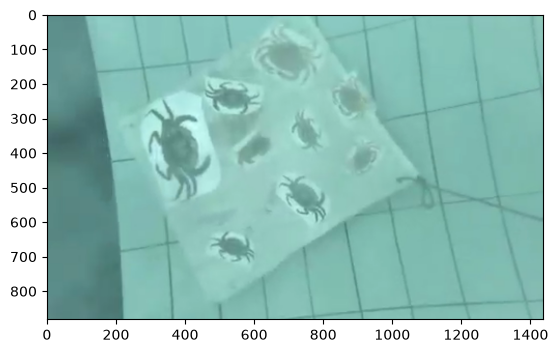

In [108]:
image  = cv2.imread('dataset/side_quest_2.png')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

In [99]:
def white_balance(img,Ashift,Bshift):
    # l = lightness A = green red B= blue yellow
    # convert to lab then shift a + b back to neutral
    lab = cv2.cvtColor(img,cv2.COLOR_BGR2LAB)
    L,A,B = cv2.split(lab)
    A = A.astype(np.float32)
    B = B.astype(np.float32)
    A = A - (np.mean(A) - 128)+Ashift
    B = B - (np.mean(B) - 128)+Bshift
    A = np.clip(A,0,255).astype(np.uint8)
    B = np.clip(B,0,255).astype(np.uint8)
    return cv2.cvtColor(cv2.merge([L , A , B]), cv2.COLOR_LAB2BGR)

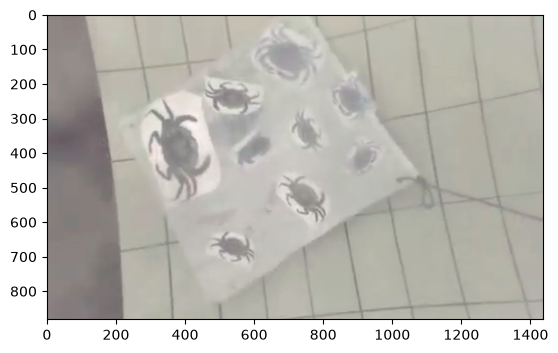

In [ ]:
imgLabcorrection = white_balance(image,0,0)
plt.imshow(imgLabcorrection)
plt.show()

In [123]:
def restoreRed (img,redStrength):
    b,g,r = cv2.split(img)
    boost = cv2.equalizeHist(r)
    strength = redStrength/100.0
    rnew = cv2.addWeighted(r,1-strength,boost,strength,0)
    return cv2.merge([b,g,rnew])

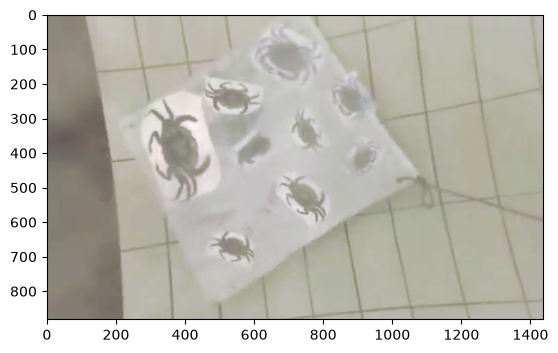

In [130]:
restoreRedimg = restoreRed(imgLabcorrection,10.0)
plt.imshow(restoreRedimg)
plt.show()

In [ ]:
!git add .
!git commit -m "not ure el ha2i2a"



* sideQuest
